In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

print("All packages imported successfully!")

All packages imported successfully!


In [3]:
import json

# Load the data
with open('../../aleph_zqq-master/analysis/zqqdaall.json', 'r') as f:
    data = json.load(f)

with open('../../aleph_zqq-master/analysis/zqqmcall.json', 'r') as f:
    mc = json.load(f)

print("Data loaded!")
print(f"Data keys: {list(data.keys())}")

Data loaded!
Data keys: ['pipi', 'pipi0', 'gammagamma', 'kpi']


In [ ]:
# Look inside pipi
pipi = data['pipi']
print(type(pipi))
print(pipi.keys() if isinstance(pipi, dict) else pipi[0])

<class 'dict'>
dict_keys(['nev', 'all', 'x'])
<class 'dict'>
dict_keys(['inv_mass', 'q'])


In [14]:
print(type(pipi['all']))
print(pipi['all'].keys() if isinstance(pipi['all'], dict) else pipi['all'][0])

<class 'dict'>
dict_keys(['inv_mass', 'q'])


In [15]:
print(pipi['all']['inv_mass'])
print(type(pipi['all']['inv_mass']))

{'same': {'bins': [0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3, 0.31, 0.32, 0.33, 0.34, 0.35000000000000003, 0.36, 0.37, 0.38, 0.39, 0.4, 0.41000000000000003, 0.42, 0.43, 0.44, 0.45, 0.46, 0.47000000000000003, 0.48, 0.49, 0.5, 0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.5700000000000001, 0.58, 0.59, 0.6, 0.61, 0.62, 0.63, 0.64, 0.65, 0.66, 0.67, 0.68, 0.6900000000000001, 0.7000000000000001, 0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79, 0.8, 0.81, 0.8200000000000001, 0.8300000000000001, 0.84, 0.85, 0.86, 0.87, 0.88, 0.89, 0.9, 0.91, 0.92, 0.93, 0.9400000000000001, 0.9500000000000001, 0.96, 0.97, 0.98, 0.99, 1.0, 1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09, 1.1, 1.11, 1.12, 1.1300000000000001, 1.1400000000000001, 1.1500000000000001, 1.16, 1.17, 1.18, 1.19, 1.2, 1.21, 1.22, 1.23, 1.24, 1.25, 1.26, 1.27, 1.28, 1.29, 1.3, 1.31, 1.32, 1.33, 1.34,

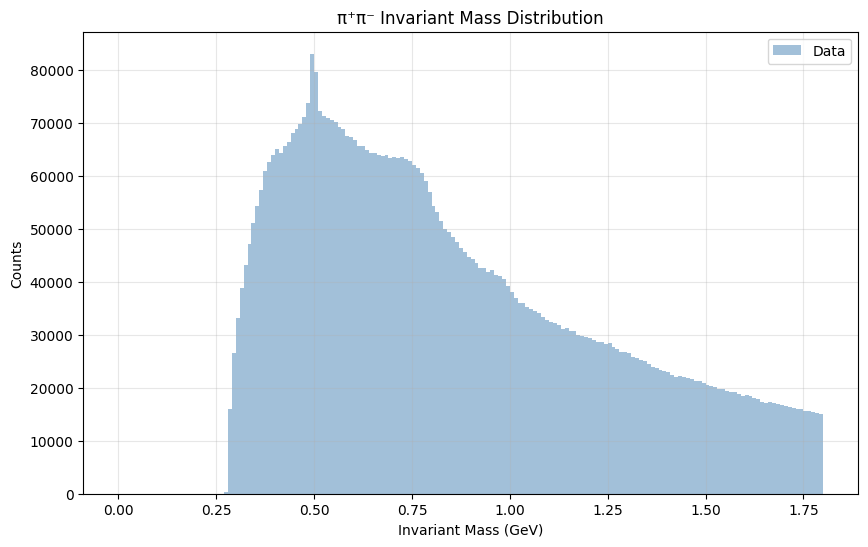

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Extract pipi opposite charge data (where K0 signal appears)
opposite = data['pipi']['all']['inv_mass']['opposite']

bins = np.array(opposite['bins'])
counts = np.array(opposite['sumW'])

# Plot
plt.figure(figsize=(10, 6))
plt.stairs(counts, bins, fill=True, alpha=0.5, color='steelblue', label='Data')
plt.xlabel('Invariant Mass (GeV)')
plt.ylabel('Counts')
plt.title('π⁺π⁻ Invariant Mass Distribution')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

YOU CAN SEE THE K⁰ PEAK! That sharp spike right at 0.498 GeV — that's it! That's the K⁰ particle showing up in real CERN data. You can also see a broader bump around 0.77 GeV which is the ρ (rho) meson, and another feature around 1.0 GeV which is the f₀/φ region.


This is already a genuinely nice plot from real data. Now let's also plot the MC on top so we can compare them, just like you did in your bachelor's project. Add a new cell:

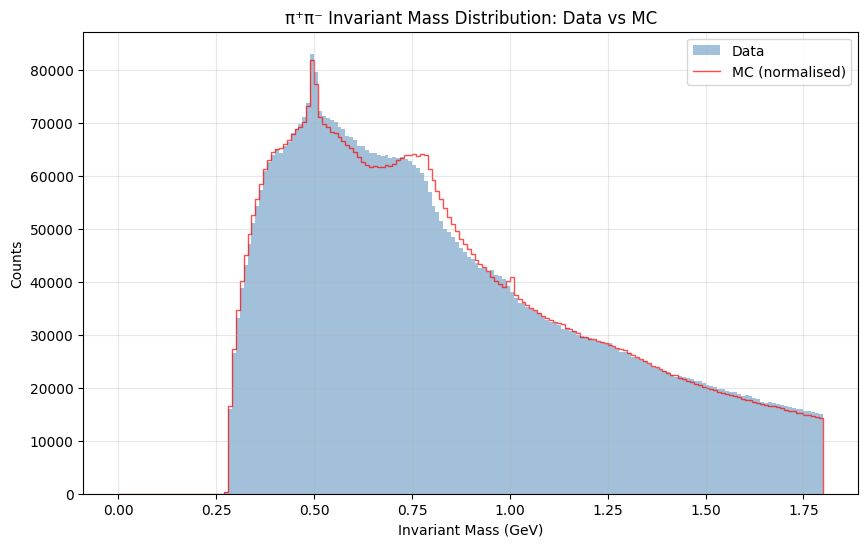

In [18]:
# Extract MC pipi opposite charge
mc_opposite = mc['pipi']['all']['inv_mass']['opposite']

mc_bins = np.array(mc_opposite['bins'])
mc_counts = np.array(mc_opposite['sumW'])

# Normalise MC to match data scale
scale = counts.sum() / mc_counts.sum()
mc_counts_scaled = mc_counts * scale

# Plot both
plt.figure(figsize=(10, 6))
plt.stairs(counts, bins, fill=True, alpha=0.5, color='steelblue', label='Data')
plt.stairs(mc_counts_scaled, mc_bins, color='red', alpha=0.7, label='MC (normalised)')
plt.xlabel('Invariant Mass (GeV)')
plt.ylabel('Counts')
plt.title('π⁺π⁻ Invariant Mass Distribution: Data vs MC')
plt.legend()
plt.grid(alpha=0.3)
plt.show()